# 03. Воронка, юнит-экономика и сегменты

Задача ноутбука — определить, на каких этапах платформа теряет пользователей и выручку, и отделить устойчивые эффекты от случайных различий.

Последовательность работы: проверка качества данных, построение сквозной воронки, расчёт юнит-экономики, анализ длительности шагов, сегментный и когортный разрезы, проверка устойчивости средних, анализ событий, статистическая проверка выявленных различий.

In [1]:
import sqlite3
from contextlib import closing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

DB_PATH = '../data/skillforge.db'
sns.set_theme(style='whitegrid', rc={'font.family': 'DejaVu Sans'})

with closing(sqlite3.connect(DB_PATH)) as conn:
    df_users = pd.read_sql_query('SELECT * FROM mart_users', conn)

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 25000 non-null  int64  
 1   registration_dt         25000 non-null  object 
 2   traffic_channel         25000 non-null  object 
 3   device_type             25000 non-null  object 
 4   country                 25000 non-null  object 
 5   onboarding_start_dt     21702 non-null  object 
 6   step_1_dt               17557 non-null  object 
 7   step_2_dt               10224 non-null  object 
 8   step_3_dt               8713 non-null   object 
 9   onboarding_complete_dt  7843 non-null   object 
 10  catalog_view_dt         9369 non-null   object 
 11  trial_start_dt          5583 non-null   object 
 12  trial_finish_dt         3949 non-null   object 
 13  paywall_view_dt         4086 non-null   object 
 14  catalog_views           25000 non-null

## Качество данных

Перед расчётом конверсий необходимо убедиться в корректности данных. Проверяются три условия: уникальность ключа, согласованность платёжных полей и хронология событий — шаг не может быть завершён раньше, чем начат.

Нарушения хронологии оформлены как `assert`. Это не наблюдение, а условие остановки: при появлении в логах нарушений временного порядка ноутбук должен прерываться, а не выдавать корректные на вид проценты.

In [2]:
assert df_users['user_id'].is_unique, 'Обнаружены дубликаты по user_id'

DATE_COLUMNS = [
    'registration_dt', 'onboarding_start_dt', 'step_1_dt', 'step_2_dt', 'step_3_dt',
    'onboarding_complete_dt', 'catalog_view_dt', 'trial_start_dt', 'trial_finish_dt',
    'paywall_view_dt', 'first_payment_dt',
]
df_users[DATE_COLUMNS] = df_users[DATE_COLUMNS].apply(pd.to_datetime)

print(f"Период когорт: с {df_users['registration_dt'].min()} по {df_users['registration_dt'].max()}")

Период когорт: с 2026-01-01 00:00:37 по 2026-06-29 23:47:50


In [3]:
for column in ['traffic_channel', 'device_type', 'country']:
    display(df_users[column].value_counts(normalize=True).mul(100).round(2).to_frame(name='share_%'))

display(
    df_users[['total_revenue', 'payments_count', 'events_count', 'unique_event_types']]
    .describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)
)

payment_checks = [
    (df_users['total_revenue'] > 0) == (df_users['payments_count'] > 0),
    (df_users['payments_count'] > 0) == df_users['first_payment_dt'].notna(),
]
assert all(check.all() for check in payment_checks), 'Расхождения в данных по платежам'

,share_%
traffic_channel,
organic,34.82
paid_search,30.02
targeted_ads,19.90
influencers,15.26


,share_%
device_type,
mobile,54.94
desktop,38.23
tablet,6.82


,share_%
country,
RU,69.68
KZ,15.44
BY,7.11
UZ,5.04
Other,2.74


,mean,std,min,50%,max
total_revenue,355.78,5325.22,0.0,0.0,732815.62
payments_count,0.06,0.30,0.0,0.0,4.00
events_count,6.81,2.87,3.0,6.0,15.00
unique_event_types,6.56,2.58,3.0,6.0,12.00


In [4]:
CHRONOLOGY_PAIRS = [
    ('registration_dt', 'onboarding_start_dt'),
    ('onboarding_start_dt', 'step_1_dt'),
    ('step_1_dt', 'step_2_dt'),
    ('step_2_dt', 'step_3_dt'),
    ('step_3_dt', 'onboarding_complete_dt'),
    ('trial_start_dt', 'trial_finish_dt'),
    ('paywall_view_dt', 'first_payment_dt'),
]

inversions = {f'{a} > {b}': (df_users[a] > df_users[b]).sum() for a, b in CHRONOLOGY_PAIRS}
assert sum(inversions.values()) == 0, f'Нарушение хронологии: {inversions}'

PREREQUISITE_PAIRS = CHRONOLOGY_PAIRS[1:5] + [
    ('onboarding_complete_dt', 'trial_start_dt'),
    ('paywall_view_dt', 'first_payment_dt'),
    ('trial_start_dt', 'first_payment_dt'),
]

skipped_steps = {
    f'{later}_без_{earlier}': (df_users[later].notna() & df_users[earlier].isna()).sum()
    for earlier, later in PREREQUISITE_PAIRS
}

display(pd.Series(skipped_steps, name='users_count').to_frame())

,users_count
step_1_dt_без_onboarding_start_dt,0
step_2_dt_без_step_1_dt,0
step_3_dt_без_step_2_dt,0
onboarding_complete_dt_без_step_3_dt,0
trial_start_dt_без_onboarding_complete_dt,2563
first_payment_dt_без_paywall_view_dt,296
first_payment_dt_без_trial_start_dt,484


Данные проходят проверку: ключ уникален, нарушений хронологии нет, платёжные поля согласованы.

Отдельного внимания заслуживает таблица пропущенных шагов. Внутри онбординга вложенность строгая — не зафиксировано ни одного случая достижения шага 2 без шага 1. За пределами онбординга строгой последовательности нет: 2 563 пользователя начали пробный урок, не завершив онбординг, 296 совершили оплату, не просматривая пейволл. Это не ошибка данных, а особенность продукта: к каталогу и оплате ведёт несколько путей.

Следствие для воронки: рассчитывать её как строгую последовательность некорректно, часть шагов требует отдельной пометки.

## Сквозная воронка

In [5]:
FUNNEL_STEPS = [
    ('Регистрация', 'registration_dt', True),
    ('Начал онбординг', 'onboarding_start_dt', True),
    ('Шаг 1', 'step_1_dt', True),
    ('Шаг 2', 'step_2_dt', True),
    ('Шаг 3', 'step_3_dt', True),
    ('Завершил онбординг', 'onboarding_complete_dt', True),
    ('Открыл каталог', 'catalog_view_dt', False),
    ('Начал пробный урок', 'trial_start_dt', True),
    ('Закончил пробный урок', 'trial_finish_dt', True),
    ('Увидел пейволл', 'paywall_view_dt', False),
    ('Первая оплата', 'first_payment_dt', False),
]

df_funnel = pd.DataFrame({
    'step': [label for label, _, _ in FUNNEL_STEPS],
    'users_count': [df_users[column].notna().sum() for _, column, _ in FUNNEL_STEPS],
    'is_nested': [nested for _, _, nested in FUNNEL_STEPS],
})

df_funnel['overall_cr_%'] = (df_funnel['users_count'] / df_funnel['users_count'].iloc[0] * 100).round(2)
df_funnel['step_cr_%'] = (df_funnel['users_count'] / df_funnel['users_count'].shift(1) * 100).round(2)
df_funnel['drop_off_%'] = (100 - df_funnel['step_cr_%']).round(2)
df_funnel.loc[~df_funnel['is_nested'], ['step_cr_%', 'drop_off_%']] = np.nan

display(df_funnel.drop(columns='is_nested'))

,step,users_count,overall_cr_%,step_cr_%,drop_off_%
0,Регистрация,25000,100.00,NaN,NaN
1,Начал онбординг,21702,86.81,86.81,13.19
2,Шаг 1,17557,70.23,80.90,19.10
3,Шаг 2,10224,40.90,58.23,41.77
4,Шаг 3,8713,34.85,85.22,14.78
5,Завершил онбординг,7843,31.37,90.01,9.99
6,Открыл каталог,9369,37.48,NaN,NaN
7,Начал пробный урок,5583,22.33,59.59,40.41
8,Закончил пробный урок,3949,15.80,70.73,29.27
9,Увидел пейволл,4086,16.34,NaN,NaN


### Распределение потерь по этапам

Из 25 000 зарегистрировавшихся пользователей до оплаты доходят 1 148, сквозная конверсия составляет 4.59%.

Наибольшая единичная потеря приходится на **шаг 2 онбординга: 41.8% отвала**. Для сравнения, смежные шаги теряют 15–19%. Ни один другой переход воронки не приводит к сопоставимым потерям.

Три шага не вложены в предыдущий, конверсия шага для них не рассчитывается:

- **каталог** открывают 9 369 пользователей, что превышает число завершивших онбординг (7 843). Часть аудитории попадает в каталог, минуя онбординг;
- **пейволл** видят 4 086 пользователей при 3 949 завершивших пробный урок;
- **оплата** возможна без просмотра пейволла.

По этой причине в таблице для указанных шагов проставлено значение `NaN`, а не конверсия выше 100%: формула, применённая к невложенному шагу, даёт бессмысленный результат.

## Юнит-экономика

In [6]:
total_revenue = df_users['total_revenue'].sum()
total_users = len(df_users)
paying_users = int((df_users['total_revenue'] > 0).sum())
total_payments = int(df_users['payments_count'].sum())

unit_economics = {
    'Всего пользователей': f'{total_users:,}',
    'Платящих пользователей': f'{paying_users:,}',
    'Конверсия в оплату (CR)': f'{paying_users / total_users * 100:.2f}%',
    'Выручка': f'{total_revenue:,.2f} ₽',
    'Транзакций': f'{total_payments:,}',
    'ARPU': f'{total_revenue / total_users:,.2f} ₽',
    'ARPPU': f'{total_revenue / paying_users:,.2f} ₽',
    'Средний чек (AOV)': f'{total_revenue / total_payments:,.2f} ₽',
    'Транзакций на платящего': f'{total_payments / paying_users:.2f}',
}

display(pd.Series(unit_economics, name='value').to_frame())

,value
Всего пользователей,"25,000"
Платящих пользователей,"1,148"
Конверсия в оплату (CR),4.59%
Выручка,"8,894,452.61 ₽"
Транзакций,"1,470"
ARPU,355.78 ₽
ARPPU,"7,747.78 ₽"
Средний чек (AOV),"6,050.65 ₽"
Транзакций на платящего,1.28


### Структура выручки

Выручка за полугодие составляет 8.89 млн ₽ при ARPU 356 ₽ и ARPPU 7 748 ₽.

Средний платящий пользователь совершает 1.28 транзакции со средним чеком 6 051 ₽. Двадцатикратный разрыв между ARPU и ARPPU определяет приоритет: основным рычагом выступает конверсия, а не размер чека. Рост конверсии на один процентный пункт при неизменном ARPPU дал бы около 1.9 млн ₽, то есть 22% к выручке. Для получения сопоставимого эффекта за счёт чека средний платёж потребовалось бы увеличить с 6 051 до 7 380 ₽.

## Длительность шагов

In [7]:
intervals = pd.DataFrame({
    'reg_to_onb_start_min': (df_users['onboarding_start_dt'] - df_users['registration_dt']).dt.total_seconds() / 60,
    'step1_to_step2_min': (df_users['step_2_dt'] - df_users['step_1_dt']).dt.total_seconds() / 60,
    'onb_duration_min': (df_users['onboarding_complete_dt'] - df_users['onboarding_start_dt']).dt.total_seconds() / 60,
    'trial_duration_min': (df_users['trial_finish_dt'] - df_users['trial_start_dt']).dt.total_seconds() / 60,
    'paywall_to_payment_min': (df_users['first_payment_dt'] - df_users['paywall_view_dt']).dt.total_seconds() / 60,
    'reg_to_payment_days': (df_users['first_payment_dt'] - df_users['registration_dt']).dt.total_seconds() / 86400,
})

time_stats = intervals.agg(['count', 'mean', 'median',
                            lambda s: s.quantile(0.75),
                            lambda s: s.quantile(0.90)]).T
time_stats.columns = ['count', 'mean', 'median', 'p75', 'p90']

display(time_stats.round(2))

,count,mean,median,p75,p90
reg_to_onb_start_min,21702.0,0.58,0.58,0.80,0.92
step1_to_step2_min,10224.0,1.92,1.92,2.63,3.07
onb_duration_min,7843.0,4.46,4.45,5.22,5.85
trial_duration_min,3949.0,29.94,30.00,38.00,42.00
paywall_to_payment_min,852.0,1394.07,82.00,128.50,2152.80
reg_to_payment_days,1148.0,0.91,0.11,0.21,1.28


### Временные характеристики пути

Онбординг занимает 4.5 минуты по медиане, переход от шага 1 к шагу 2 — менее двух минут. То есть отвал на шаге 2 происходит не после длительного взаимодействия, а почти сразу. Что именно останавливает пользователей, по логам не определяется: причина требует проверки экспериментом или качественным исследованием.

Путь до оплаты короткий: медиана от регистрации до платежа составляет 0.11 дня, около двух с половиной часов.

От просмотра пейволла до оплаты медиана составляет 82 минуты, при этом 90-й перцентиль — 2 153 минуты, почти полтора суток. У десятой части платящих пользователей решение о покупке растянуто на сутки и более.

## Сегментный анализ

In [8]:
def segment_metrics(dimension):
    segment = df_users.groupby(dimension).agg(
        total_users=('user_id', 'count'),
        onb_cr=('onboarding_complete_dt', lambda s: s.notna().mean() * 100),
        catalog_cr=('catalog_view_dt', lambda s: s.notna().mean() * 100),
        trial_cr=('trial_start_dt', lambda s: s.notna().mean() * 100),
        payment_cr=('first_payment_dt', lambda s: s.notna().mean() * 100),
        arpu=('total_revenue', 'mean'),
        arppu=('total_revenue', lambda s: s[s > 0].mean()),
    )
    segment['users_share_%'] = segment['total_users'] / len(df_users) * 100
    return segment.sort_values('total_users', ascending=False).round(2).reset_index()


device_segment = segment_metrics('device_type')
channel_segment = segment_metrics('traffic_channel')
country_segment = segment_metrics('country')

display(device_segment, channel_segment, country_segment)

,device_type,total_users,onb_cr,catalog_cr,trial_cr,payment_cr,arpu,arppu,users_share_%
0,mobile,13736,28.46,35.83,21.24,4.36,371.44,8517.75,54.94
1,desktop,9558,37.58,40.23,24.17,5.04,354.60,7031.69,38.23
2,tablet,1706,20.05,35.35,20.81,3.93,236.25,6015.57,6.82


,traffic_channel,total_users,onb_cr,catalog_cr,trial_cr,payment_cr,arpu,arppu,users_share_%
0,organic,8704,31.93,37.09,22.27,4.70,297.11,6322.83,34.82
1,paid_search,7506,32.48,38.52,23.07,4.90,457.70,9335.52,30.02
2,targeted_ads,4974,29.61,37.56,22.01,4.32,353.83,8185.75,19.90
3,influencers,3816,30.21,36.22,21.44,4.09,291.67,7134.68,15.26


,country,total_users,onb_cr,catalog_cr,trial_cr,payment_cr,arpu,arppu,users_share_%
0,RU,17419,30.77,37.36,22.21,4.62,327.59,7088.65,69.68
1,KZ,3860,32.80,37.62,23.50,4.38,323.29,7383.98,15.44
2,BY,1777,33.26,38.27,22.45,4.22,304.73,7220.16,7.11
3,UZ,1259,32.01,36.93,20.81,4.53,877.04,19371.85,5.04
4,Other,685,32.55,38.69,21.31,6.13,429.91,7011.67,2.74


In [9]:
pivot_users = df_users.pivot_table(
    index='traffic_channel', columns='device_type', values='user_id', aggfunc='count')

pivot_payment_cr = df_users.pivot_table(
    index='traffic_channel', columns='device_type', values='first_payment_dt',
    aggfunc=lambda s: s.notna().mean() * 100).round(2)

pivot_arpu = df_users.pivot_table(
    index='traffic_channel', columns='device_type', values='total_revenue',
    aggfunc='mean').round(2)

display(pivot_users, pivot_payment_cr, pivot_arpu)

device_type,desktop,mobile,tablet
traffic_channel,,,
influencers,1422,2117,277
organic,3290,4813,601
paid_search,2913,4098,495
targeted_ads,1933,2708,333


device_type,desktop,mobile,tablet
traffic_channel,,,
influencers,4.36,3.92,3.97
organic,5.53,4.34,3.00
paid_search,5.01,5.00,3.43
targeted_ads,4.76,3.77,6.31


device_type,desktop,mobile,tablet
traffic_channel,,,
influencers,351.33,265.72,183.75
organic,344.67,281.79,159.40
paid_search,368.87,546.54,244.88
targeted_ads,352.41,348.45,405.80


### Различия по устройствам значимы, по каналам — нет

Разрыв по устройствам существенный и последовательный: онбординг завершают 37.6% пользователей десктопа, 28.5% мобильных устройств и 20.1% планшетов. Конверсия в оплату составляет 5.04%, 4.36% и 3.93% соответственно.

Существенно, на каком сегменте этот разрыв реализуется: мобильные устройства составляют 55% всей аудитории. Девять процентных пунктов разницы в доходимости онбординга на крупнейшем сегменте и образуют основной источник потерь.

Каналы привлечения различаются незначительно: конверсия в оплату варьируется от 4.09% у инфлюенсеров до 4.90% у платного поиска, разброс менее одного процентного пункта. На этом фоне ARPU платного поиска в 458 ₽ против 292 ₽ у инфлюенсеров требует проверки: при близких конверсиях средний доход отличается в полтора раза. Это первый признак искажения средних по выручке.

## Когортный анализ

In [10]:
cohorts = df_users.assign(
    reg_month=df_users['registration_dt'].dt.to_period('M')
).groupby('reg_month').agg(
    cohort_size=('user_id', 'count'),
    onb_cr=('onboarding_complete_dt', lambda s: s.notna().mean() * 100),
    trial_cr=('trial_start_dt', lambda s: s.notna().mean() * 100),
    payment_cr=('first_payment_dt', lambda s: s.notna().mean() * 100),
    total_revenue=('total_revenue', 'sum'),
    arpu=('total_revenue', 'mean'),
    arppu=('total_revenue', lambda s: s[s > 0].mean()),
).round(2).reset_index()

display(cohorts)

,reg_month,cohort_size,onb_cr,trial_cr,payment_cr,total_revenue,arpu,arppu
0,2026-01,4273,30.19,22.77,4.87,1459006.93,341.45,7014.46
1,2026-02,3949,31.81,22.79,4.89,1490040.45,377.32,7720.42
2,2026-03,4358,31.25,22.26,4.34,1521249.43,349.07,8048.94
3,2026-04,4063,31.13,22.64,4.77,1413171.56,347.81,7284.39
4,2026-05,4339,31.00,21.85,4.52,2095049.75,482.84,10689.03
5,2026-06,4018,32.98,21.70,4.18,915934.49,227.96,5451.99


### Конверсия стабильна, показатели выручки нестабильны

Помесячная конверсия в оплату остаётся в диапазоне 4.18–4.89%, доходимость онбординга — 30–33%. Поведение пользователей от месяца к месяцу не изменяется.

При этом ARPU колеблется от 228 до 483 ₽, ARPPU — от 5 452 до 10 689 ₽, то есть вдвое. При стабильной конверсии такая динамика может объясняться только размером чеков. Требуется определить, обусловлена ли она сдвигом тарифной сетки или влиянием отдельных крупных сделок.

## Проверка устойчивости средних

In [11]:
ENTERPRISE_REVENUE_THRESHOLD = 45_000

df_users['is_enterprise'] = df_users['total_revenue'] >= ENTERPRISE_REVENUE_THRESHOLD
df_users['reg_month'] = df_users['registration_dt'].dt.to_period('M')

enterprise_users = int(df_users['is_enterprise'].sum())
enterprise_revenue_share = (
    df_users.loc[df_users['is_enterprise'], 'total_revenue'].sum() / df_users['total_revenue'].sum() * 100
)

print(f'Крупных сделок: {enterprise_users} пользователей '
      f'({enterprise_users / len(df_users) * 100:.2f}% базы), {enterprise_revenue_share:.1f}% всей выручки')


def arpu_with_and_without_tail(dimension):
    return pd.DataFrame({
        'arpu_all': df_users.groupby(dimension)['total_revenue'].mean(),
        'arpu_no_tail': df_users[~df_users['is_enterprise']].groupby(dimension)['total_revenue'].mean(),
    }).assign(
        tail_effect_pct=lambda frame: (frame['arpu_all'] / frame['arpu_no_tail'] - 1) * 100
    ).round(2)


display(arpu_with_and_without_tail('traffic_channel'), arpu_with_and_without_tail('reg_month'))

Крупных сделок: 24 пользователей (0.10% базы), 23.8% всей выручки


,arpu_all,arpu_no_tail,tail_effect_pct
traffic_channel,,,
influencers,291.67,249.48,16.91
organic,297.11,264.27,12.42
paid_search,457.70,308.47,48.37
targeted_ads,353.83,243.91,45.06


,arpu_all,arpu_no_tail,tail_effect_pct
reg_month,,,
2026-01,341.45,291.36,17.19
2026-02,377.32,289.72,30.24
2026-03,349.07,273.44,27.66
2026-04,347.81,303.54,14.59
2026-05,482.84,274.98,75.59
2026-06,227.96,192.60,18.36


### Влияние крупных сделок на средние показатели

24 пользователя, что составляет одну десятую процента базы, обеспечивают **23.8% всей выручки**.

При их исключении картина существенно меняется. ARPU платного поиска снижается с 458 до 308 ₽: почти половина его превосходства обусловлена несколькими B2B-сделками. Майский рост ARPU до 483 ₽ без учёта хвоста составляет 275 ₽, то есть соответствует среднему уровню остальных месяцев, и в действительности отсутствует.

Два практических следствия:

1. Решения не могут приниматься на основе среднего чека или ARPU без исключения хвоста. Различия между каналами и месяцами, наблюдаемые в предыдущих таблицах, преимущественно обусловлены влиянием отдельных платежей.
2. Крупные сделки следует выделить в отдельное направление анализа. 0.1% пользователей, обеспечивающих четверть выручки, представляют собой не выброс, подлежащий исключению, а самостоятельный B2B-сегмент с собственной экономикой.

## Анализ событий

In [12]:
with closing(sqlite3.connect(DB_PATH)) as conn:
    df_events = pd.read_sql_query('SELECT * FROM mart_events', conn)

df_events[['event_dt', 'previous_event_dt']] = df_events[['event_dt', 'previous_event_dt']].apply(pd.to_datetime)

events_distribution = df_events.groupby('event_name').agg(
    total_events=('event_id', 'count'),
    unique_users=('user_id', 'nunique'),
).assign(
    events_per_user=lambda df: (df['total_events'] / df['unique_users']).round(2),
    user_reach_pct=lambda df: (df['unique_users'] / df_users['user_id'].nunique() * 100).round(2),
).sort_values('total_events', ascending=False).reset_index()

print(f"Всего событий: {len(df_events):,} | пользователей: {df_events['user_id'].nunique():,}")
display(events_distribution)

Всего событий: 170,219 | пользователей: 25,000


,event_name,total_events,unique_users,events_per_user,user_reach_pct
0,complete_registration,25000,25000,1.00,100.00
1,start_registration,25000,25000,1.00,100.00
2,view_landing,25000,25000,1.00,100.00
3,start_onboarding,21702,21702,1.00,86.81
4,complete_step_1,17557,17557,1.00,70.23
5,view_catalog,14641,9369,1.56,37.48
6,complete_step_2,10224,10224,1.00,40.90
7,complete_step_3,8713,8713,1.00,34.85
8,complete_onboarding,7843,7843,1.00,31.37
9,start_trial_lesson,5583,5583,1.00,22.33


### Источники перехода в каталог

Из 170 тысяч событий повторяются только два типа: каталог просматривается в среднем 1.56 раза, пейволл — 1.23 раза. Остальные события происходят у пользователя однократно, вследствие чего число событий и число уникальных типов близки.

Переходы в каталог показывают отсутствие единой точки входа: 5 089 переходов совершается после завершённого онбординга, 1 822 — непосредственно с первого шага, 1 037 — со старта онбординга, 841 — сразу после регистрации. Более пяти тысяч переходов представляют собой повторные обращения к каталогу.

Половина трафика в каталог проходит мимо полного онбординга. Это наблюдение показывает, что путь в каталог в обход онбординга уже существует и им пользуются; вывод о том, как размещение более ранней точки входа повлияет на прохождение онбординга, из него не следует и проверяется экспериментом.

In [13]:
display(
    df_events.loc[df_events['event_name'] == 'view_catalog', 'previous_event']
    .value_counts(dropna=False)
    .to_frame(name='transitions_count')
)

df_users['viewed_catalog'] = df_users['catalog_view_dt'].notna()

catalog_impact = df_users.groupby('viewed_catalog').agg(
    total_users=('user_id', 'count'),
    trial_cr=('trial_start_dt', lambda s: s.notna().mean() * 100),
    payment_cr=('first_payment_dt', lambda s: s.notna().mean() * 100),
    arpu=('total_revenue', 'mean'),
    arppu=('total_revenue', lambda s: s[s > 0].mean()),
).round(2).reset_index()

display(catalog_impact)

,transitions_count
previous_event,
view_catalog,5272
complete_onboarding,5089
complete_step_1,1822
start_onboarding,1037
complete_registration,841
complete_step_2,373
complete_step_3,207


,viewed_catalog,total_users,trial_cr,payment_cr,arpu,arppu
0,False,15631,0.00,1.38,101.44,7340.49
1,True,9369,59.59,9.95,780.12,7842.18


### Связь просмотра каталога с оплатой

Разрыв значительный: у пользователей, открывших каталог, конверсия в оплату составляет 9.95%, у остальных — 1.38%. Различие семикратное, ARPU отличается в семь с половиной раз.

Более информативно то, что различается незначительно: ARPPU составляет 7 842 ₽ у открывших каталог и 7 340 ₽ у остальных. Каталог влияет на решение о покупке, но не на размер чека. Следовательно, работать с ним следует как с инструментом активации, а не увеличения среднего чека.

## Статистическая проверка

In [14]:
def compare_proportions(sample_a, sample_b, label):
    """Двусторонний z-тест разницы двух независимых пропорций."""
    n_a, n_b = len(sample_a), len(sample_b)
    p_a, p_b = sample_a.mean(), sample_b.mean()

    pooled = (sample_a.sum() + sample_b.sum()) / (n_a + n_b)
    standard_error = np.sqrt(pooled * (1 - pooled) * (1 / n_a + 1 / n_b))
    z_stat = (p_a - p_b) / standard_error
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return {
        'Сравнение': label,
        'Группа 1': f'{p_a * 100:.2f}% (n={n_a:,})',
        'Группа 2': f'{p_b * 100:.2f}% (n={n_b:,})',
        'Разница (п.п.)': round((p_a - p_b) * 100, 2),
        'p-value': f'{p_value:.4e}',
        'Значимо': p_value < 0.05,
    }


is_paying = df_users['first_payment_dt'].notna().astype(int)

comparisons = [
    (is_paying[df_users['viewed_catalog']], is_paying[~df_users['viewed_catalog']],
     'Каталог: открыл vs нет'),
    (is_paying[df_users['device_type'] == 'desktop'], is_paying[df_users['device_type'] == 'mobile'],
     'Устройство: desktop vs mobile'),
    (is_paying[df_users['traffic_channel'] == 'organic'], is_paying[df_users['traffic_channel'] == 'paid_search'],
     'Канал: organic vs paid_search'),
    (is_paying[df_users['country'] == 'UZ'], is_paying[df_users['country'] == 'RU'],
     'Страна: UZ vs RU'),
]

display(pd.DataFrame([compare_proportions(a, b, label) for a, b, label in comparisons]))

,Сравнение,Группа 1,Группа 2,Разница (п.п.),p-value,Значимо
0,Каталог: открыл vs нет,"9.95% (n=9,369)","1.38% (n=15,631)",8.57,0.0000e+00,True
1,Устройство: desktop vs mobile,"5.04% (n=9,558)","4.36% (n=13,736)",0.68,1.4923e-02,True
2,Канал: organic vs paid_search,"4.70% (n=8,704)","4.90% (n=7,506)",-0.20,5.4483e-01,False
3,Страна: UZ vs RU,"4.53% (n=1,259)","4.62% (n=17,419)",-0.09,8.7801e-01,False


### Результаты проверки

| Сравнение | Разница | p-value | Вывод |
|---|---|---|---|
| Каталог: открыл vs нет | +8.57 п.п. | < 0.001 | эффект подтверждён |
| Устройство: desktop vs mobile | +0.68 п.п. | 0.015 | эффект подтверждён, но в 12 раз слабее |
| Канал: organic vs paid_search | −0.20 п.п. | 0.545 | различий нет |
| Страна: UZ vs RU | −0.09 п.п. | 0.878 | различий нет |

Каналы и страны различаются в пределах случайности. Персонализация под канал, предполагаемая по результатам сегментной таблицы, привела бы к оптимизации случайных колебаний.

**Существенная оговорка.** Связь между просмотром каталога и оплатой получена наблюдением, а не экспериментом. Пользователь, дошедший до каталога, изначально более мотивирован, и часть разрыва объясняется этим отбором, а не влиянием каталога. Причинный характер эффекта может быть установлен только рандомизированным экспериментом, что является предметом ноутбука 04.

## Сводная визуализация

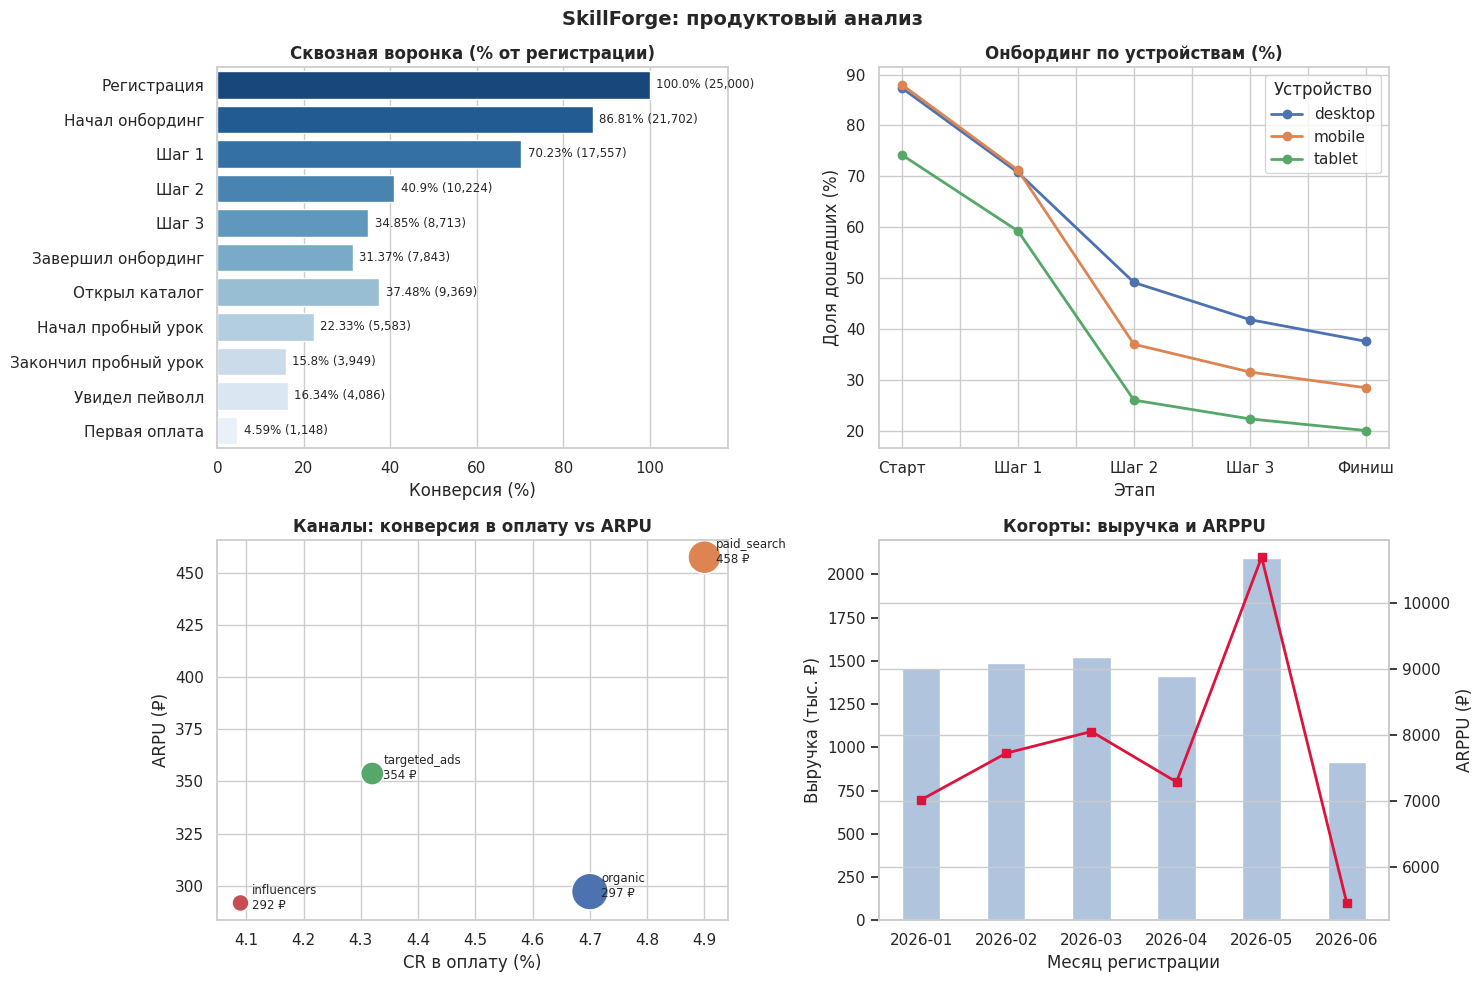

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SkillForge: продуктовый анализ', fontsize=14, fontweight='bold', y=0.98)

sns.barplot(data=df_funnel, x='overall_cr_%', y='step', ax=axes[0, 0],
            hue='step', palette='Blues_r', legend=False)
axes[0, 0].set_title('Сквозная воронка (% от регистрации)', fontweight='bold')
axes[0, 0].set_xlabel('Конверсия (%)')
axes[0, 0].set_ylabel('')
axes[0, 0].set_xlim(0, 118)

for position, (conversion, users) in enumerate(zip(df_funnel['overall_cr_%'], df_funnel['users_count'])):
    axes[0, 0].text(conversion + 1.5, position, f'{conversion}% ({users:,})', va='center', fontsize=8.5)

ONBOARDING_STEPS = ['onboarding_start_dt', 'step_1_dt', 'step_2_dt', 'step_3_dt', 'onboarding_complete_dt']
STEP_LABELS = ['Старт', 'Шаг 1', 'Шаг 2', 'Шаг 3', 'Финиш']

onboarding_by_device = (
    df_users.groupby('device_type')[ONBOARDING_STEPS]
    .apply(lambda group: group.notna().mean() * 100)
    .rename(columns=dict(zip(ONBOARDING_STEPS, STEP_LABELS)))
    .T
)

onboarding_by_device.plot(ax=axes[0, 1], marker='o', linewidth=2)
axes[0, 1].set_title('Онбординг по устройствам (%)', fontweight='bold')
axes[0, 1].set_ylabel('Доля дошедших (%)')
axes[0, 1].set_xlabel('Этап')
axes[0, 1].legend(title='Устройство')

sns.scatterplot(data=channel_segment, x='payment_cr', y='arpu', size='total_users',
                hue='traffic_channel', sizes=(150, 700), ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Каналы: конверсия в оплату vs ARPU', fontweight='bold')
axes[1, 0].set_xlabel('CR в оплату (%)')
axes[1, 0].set_ylabel('ARPU (₽)')

for _, row in channel_segment.iterrows():
    axes[1, 0].annotate(f"{row['traffic_channel']}\n{row['arpu']:.0f} ₽",
                        (row['payment_cr'], row['arpu']),
                        textcoords='offset points', xytext=(8, -4), fontsize=8.5)

cohort_labels = cohorts['reg_month'].astype(str)
revenue_axis = axes[1, 1]
arppu_axis = revenue_axis.twinx()

revenue_axis.bar(cohort_labels, cohorts['total_revenue'] / 1000,
                 color='lightsteelblue', width=0.45)
arppu_axis.plot(cohort_labels, cohorts['arppu'], color='crimson', marker='s', linewidth=2)

revenue_axis.set_title('Когорты: выручка и ARPPU', fontweight='bold')
revenue_axis.set_xlabel('Месяц регистрации')
revenue_axis.set_ylabel('Выручка (тыс. ₽)')
arppu_axis.set_ylabel('ARPPU (₽)')
revenue_axis.grid(False)

plt.tight_layout()
plt.show()

## Выводы

1. **Шаг 2 онбординга представляет собой основное узкое место воронки:** 41.8% отвала, при этом наихудшие показатели зафиксированы на мобильных устройствах, составляющих 55% аудитории.
2. **Просмотр каталога является наиболее сильным наблюдаемым предиктором оплаты:** 9.95% против 1.38%. До каталога доходят только 37.5% пользователей, при этом половина переходов совершается минуя полный онбординг.
3. **Каналы и страны между собой не различаются:** разница в конверсии статистически неотличима от нуля.
4. **Средние показатели по выручке недостоверны:** 0.1% пользователей обеспечивают 23.8% выручки, и без исключения хвоста ARPU демонстрирует различия, которые в действительности отсутствуют.

Приоритетная гипотеза — обеспечение раннего входа в каталог. Она затрагивает всех новых пользователей, опирается на наиболее выраженный из выявленных эффектов и требует минимальной доработки интерфейса. Проверка проводится экспериментом в ноутбуке 04.